<span style="font-size:35px; font-weight:bold;margin-left: 150px;color:#06445e;"> Time Series Breakdown of Walmart Sales</span>
<br>
<span style="font-size:35px; font-weight:bold;margin-left: 160px;color:#06445e;"> ----------------------------------------------</span>

<span style="font-size:30px; font-weight:bold;color:#06445e;"> (1) Import necessary libraries </span>

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from rich import print

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)



<span style="font-size:55px; font-weight:bold;color:#06445e;">______________________________________________</span>
<span style="font-size:35px; font-weight:bold;color:#06445e;"> (2) Prepare Data </span>

In [122]:
features = pd.read_csv("features.csv")
stores   = pd.read_csv("stores.csv")
test     = pd.read_csv("test.csv")
train    = pd.read_csv("train.csv")

print("[bold red]Shapes → train:[/bold red]", train.shape,
      "\n"
      "|[bold red]test:[/bold red]", test.shape,
      "\n"
      "| [bold red]features:[/bold red]", features.shape,
      "\n"
      "| [bold red]stores:[/bold red]", stores.shape,
      "\n")

Shapes → train:
(421570, 5)

|test:
(115064, 4)

| features:
(8190, 12)

| stores:
(45, 3)

<span style="font-size:25px; font-weight:bold;color:#06445e;">Display basic information about each dataset </span>

In [125]:
print("[bold underline blue]TRAIN DATASET[/bold underline blue]")
print("[bold red]Shape:[/bold red]", train.shape)
print("\n[bold red]First 5 rows:[/bold red]")
display(train.head())
print("\n[bold red]Info:[/bold red]")
print(train.info())
print("\n[bold red]Summary statistics:[/bold red]")
print(train.describe())
print("[bold red]=[/bold red]" *50)

print("\n\nS[bold underline blue]TORES DATASET[/bold underline blue]")
print("[bold red]Shape:[/bold red]", stores.shape)
print("\n[bold red]First 5 rows:[/bold red]")
display(stores.head())

print("\n\n[bold underline blue]FEATURES DATASET[/bold underline blue]")
print("[bold red]Shape:[/bold red]", features.shape)
print("\n[bold red]First 5 rows:[/bold red]")
display(features.head())

TRAIN DATASET

Shape:
(421570, 5)

First 5 rows:

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


Info:

...

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


FEATURES DATASET

Shape:
(8190, 12)

First 5 rows:

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


<span style="font-size:25px; font-weight:bold;color:#06445e;">Missing Values?? </span>

In [492]:
print(train.isnull().values.any())

False

In [500]:
print(stores.isnull().values.any())

False

In [502]:
print(features.isnull().values.any())

True

In [504]:
print("\nMissing Values (True = Missing):")
print(features.isnull())

Missing Values (True = Missing):

Store   Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  MarkDown3  \
0     False  False        False       False       True       True       True   
1     False  False        False       False       True       True       True   
2     False  False        False       False       True       True       True   
3     False  False        False       False       True       True       True   
4     False  False        False       False       True       True       True   
...     ...    ...          ...         ...        ...        ...        ...   
8185  False  False        False       False      False      False      False   
8186  False  False        False       False      False      False      False   
8187  False  False        False       False      False      False      False   
8188  False  False        False       False      False      False      False   
8189  False  False        False       False      False      False      False   

      MarkDown4  MarkDown5    CPI  Unemployment  IsHoliday  
0          True       True  False         False      False  
1          True       True  False         False      False  
2          True       True  False         False      False  
3          True       True  False         False      False  
4          True       True  False         False      False  
...         ...        ...    ...           ...        ...  
8185      False      False   True          True      False  
8186      False      False   True          True      False  
8187      False      False   True          True      False  
8188      False      False   True          True      False  
8189      False      False   True          True      False  

[8190 rows x 12 columns]

In [506]:
# Total missing values per column
print(features.isnull().sum())

Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

In [508]:
print("[bold][italic]\nTotal Missing Values in the Dataset:[/bold][/italic]")
print(features.isnull().sum().sum())

Total Missing Values in the Dataset:

24040

In [510]:
print(features.isna().sum().sort_values(ascending=False).head(20))

MarkDown2       5269
MarkDown4       4726
MarkDown3       4577
MarkDown1       4158
MarkDown5       4140
CPI              585
Unemployment     585
Store              0
Date               0
Temperature        0
Fuel_Price         0
IsHoliday          0
dtype: int64

<span style="font-size:25px; font-weight:bold;color:#06445e;">plot the null values in each column</span>

<Axes: >

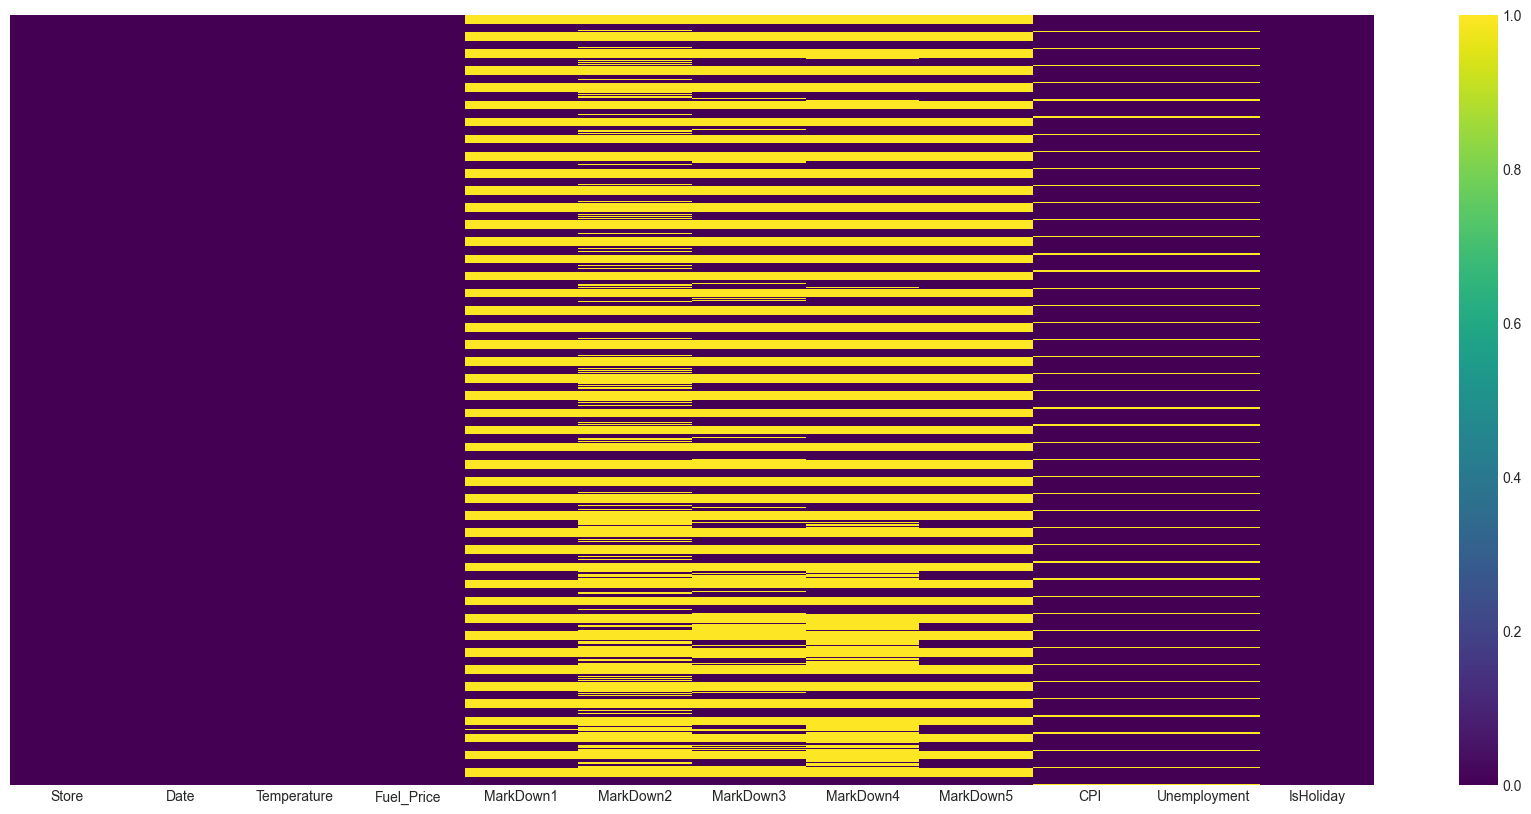

In [495]:
plt.figure(figsize=(22, 10))
sns.heatmap(features.isnull(), yticklabels=False, cbar=True, cmap='viridis')

<span style="font-size:25px; font-weight:bold;color:#06445e;">plot the null values in each column(Percent %)</span>

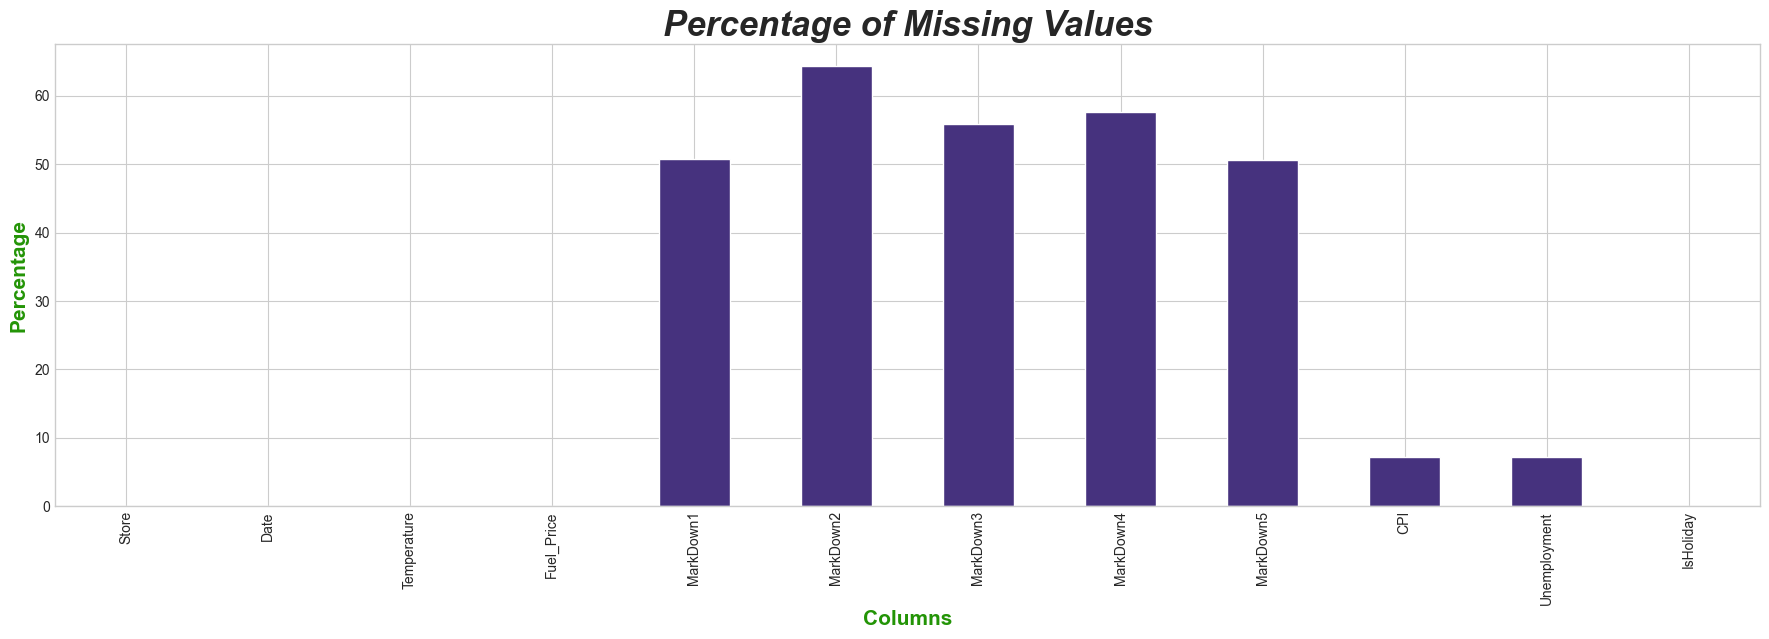

In [498]:
missing_percentage = features.isnull().sum() / len(features) * 100

plt.figure(figsize=(22, 6))
missing_percentage.plot(kind='bar')
plt.xlabel('Columns', fontsize=15, fontweight='bold', color="#239406")
plt.ylabel('Percentage', fontsize=15, fontweight='bold', color="#239406")
plt.title('Percentage of Missing Values', fontsize=25, fontweight='bold', style='italic')
plt.show()

<span style="font-size:25px; font-weight:bold;color:#06445e;">Any Duplicates??</span>

In [525]:
print(train.duplicated().any())

False

In [527]:
print(stores.duplicated().any())

False

In [529]:
print(features.duplicated().any())

False

<span style="font-size:55px; font-weight:bold">______________________________________________</span>
<span style="font-size:35px; font-weight:bold;color:#06445e;">(3) Merge everything into one tidy table (monthly grain)</span>

In [128]:
print("TRAIN columns :", list(train.columns))
print("TEST  columns :", list(test.columns))
print("STORES columns:", list(stores.columns))
print("FEATURES cols :", list(features.columns))

TRAIN columns :
['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

TEST  columns :
['Store', 'Dept', 'Date', 'IsHoliday']

STORES columns:
['Store', 'Type', 'Size']

FEATURES cols :
[
    'Store',
    'Date',
    'Temperature',
    'Fuel_Price',
    'MarkDown1',
    'MarkDown2',
    'MarkDown3',
    'MarkDown4',
    'MarkDown5',
    'CPI',
    'Unemployment',
    'IsHoliday'
]

In [134]:
features["date"] = pd.to_datetime(features["date"])
features["YearMonth"] = features["date"].dt.to_period("M").dt.to_timestamp()

In [138]:
# ------------------------------------------------------------------
# 2-A  Convert weekly date to a month-end
# ------------------------------------------------------------------
for df in [train, test, features]:
    df["Date"] = pd.to_datetime(df["Date"])
    df["Year"]  = df.Date.dt.year
    df["Month"] = df.Date.dt.month
    df["YearMonth"] = df["Date"].dt.to_period("M").dt.to_timestamp()

# ------------------------------------------------------------------
# 2-B  Aggregate weekly sales → monthly sales
# ------------------------------------------------------------------
monthly = (
    train
    .groupby(["Store", "Dept", "YearMonth"])["Weekly_Sales"]
    .sum()
    .reset_index()
    .rename(columns={"Weekly_Sales": "Monthly_Sales"})
)

# ------------------------------------------------------------------
# 2-C  Join store & features data
# ------------------------------------------------------------------
monthly = monthly.merge(stores, on="Store", how="left")
monthly = monthly.merge(
    features.groupby(["Store", "YearMonth"])
            .agg({"Temperature":"mean","Fuel_Price":"mean",
                  "CPI":"mean","Unemployment":"mean"})
            .reset_index(),
    on=["Store","YearMonth"], how="left"
)
monthly.head()

,Store,Dept,YearMonth,Monthly_Sales,Type,Size,Temperature,Fuel_Price,CPI,Unemployment
0,1,1,2010-02-01,131963.08,A,151315,41.8450,2.54875,211.236828,8.106
1,1,1,2010-03-01,91237.14,A,151315,52.5800,2.68600,211.241116,8.106
2,1,1,2010-04-01,150516.76,A,151315,65.3400,2.77440,210.552135,7.808
3,1,1,2010-05-01,66694.15,A,151315,76.0525,2.81850,210.547812,7.808
4,1,1,2010-06-01,66740.70,A,151315,82.3925,2.66575,211.356237,7.808


<span style="font-size:55px; font-weight:bold">______________________________________________</span>
<span style="font-size:35px; font-weight:bold;color:#06445e;">(4) Visualization🔮 </span>
<br>
<span style="font-size:25px; font-weight:bold;color:#06445e;">Line Plot: overall revenue trend📈📉</span>

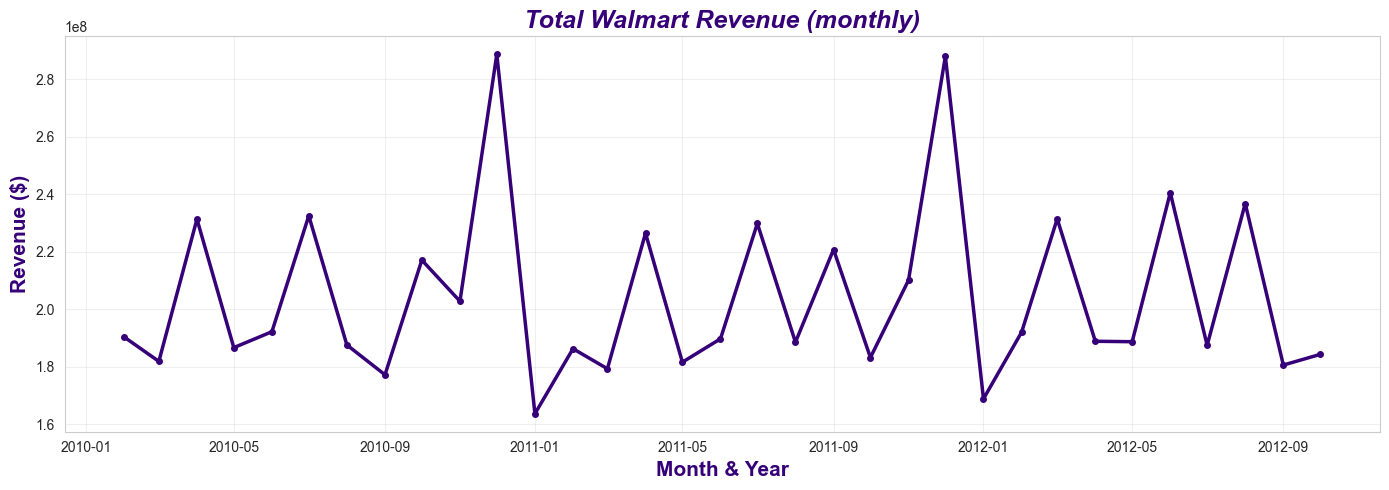

In [155]:
revenue_ts = monthly.groupby("YearMonth")["Monthly_Sales"].sum()

plt.figure(figsize=(14, 5))
plt.plot(revenue_ts.index, revenue_ts.values,            # ← actual line
         color='#360078', lw=2.5, marker='o', markersize=4)

plt.title('Total Walmart Revenue (monthly)', fontsize=18,
          fontweight='bold', style='italic', color='#360078')
plt.xlabel('Month & Year', fontsize=15, fontweight='bold', color='#360078')
plt.ylabel('Revenue ($)',  fontsize=15, fontweight='bold', color='#360078')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<span style="font-size:35px; font-weight:bold;color:#06445e;">Trend, Seasonality & Moving Averages</span>
<br>
<span style="font-size:25px; font-weight:bold;color:#06445e;">(V1) Decompose the aggregate series</span>

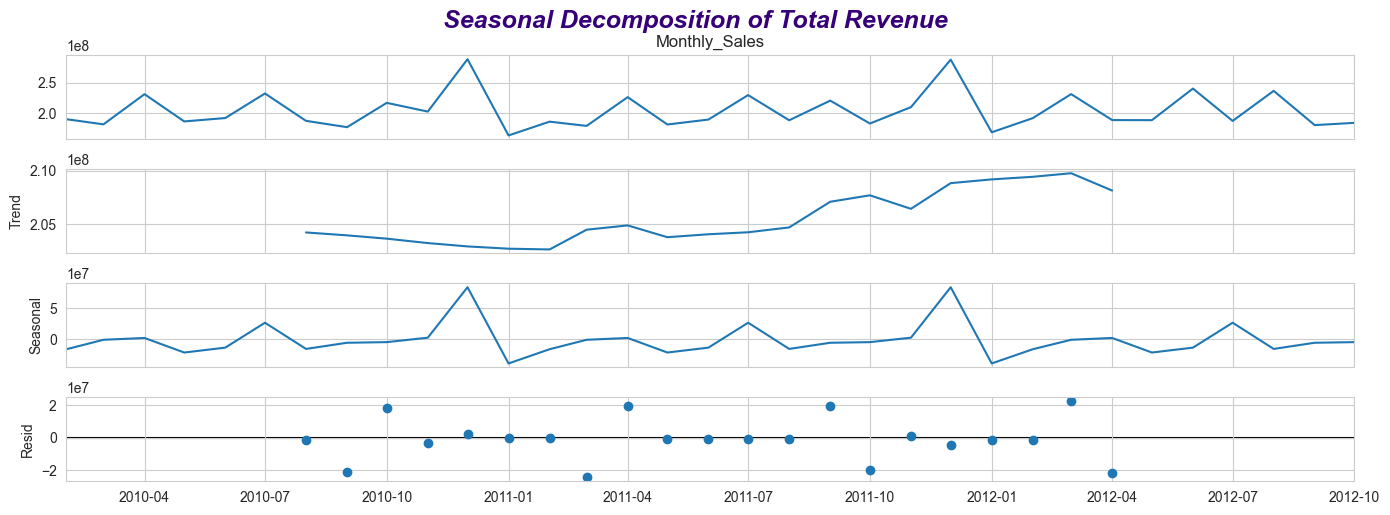

In [157]:
decomp = seasonal_decompose(revenue_ts, model="additive", period=12)
decomp.plot()
plt.suptitle("Seasonal Decomposition of Total Revenue", y=1.02, fontsize=18,
          fontweight='bold', style='italic', color='#360078')
plt.show()

<span style="font-size:25px; font-weight:bold;color:#06445e;">(V2) Simple 3- & 12-month moving averages</span>

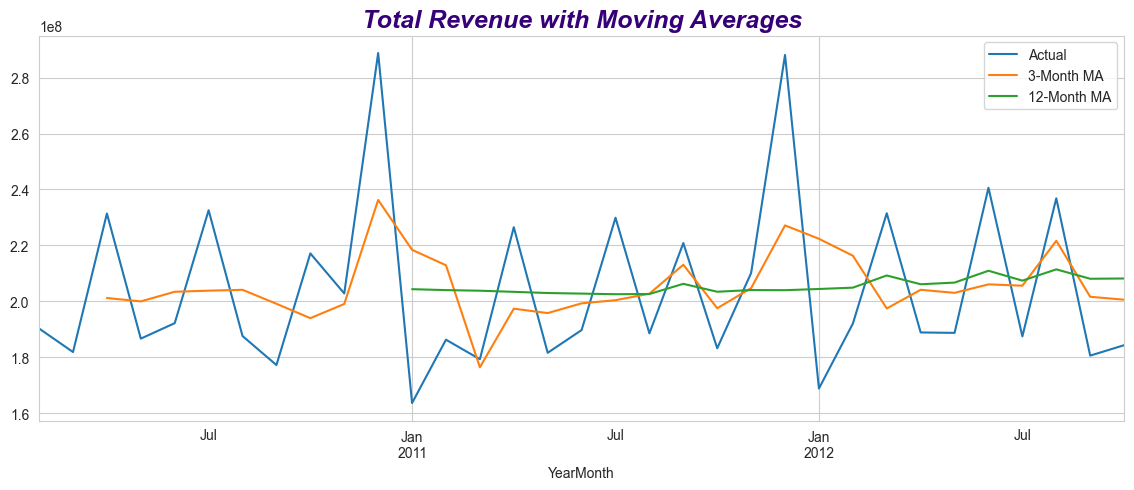

In [159]:
revenue_ts_ma3  = revenue_ts.rolling(window=3).mean()
revenue_ts_ma12 = revenue_ts.rolling(window=12).mean()

ax = revenue_ts.plot(label="Actual")
revenue_ts_ma3.plot(ax=ax, label="3-Month MA")
revenue_ts_ma12.plot(ax=ax, label="12-Month MA")
plt.title("Total Revenue with Moving Averages", fontsize=18,
          fontweight='bold', style='italic', color='#360078')
plt.legend()
plt.show()

<span style="font-size:35px; font-weight:bold;color:#06445e;">(V3) Revenue by Region over time</span>

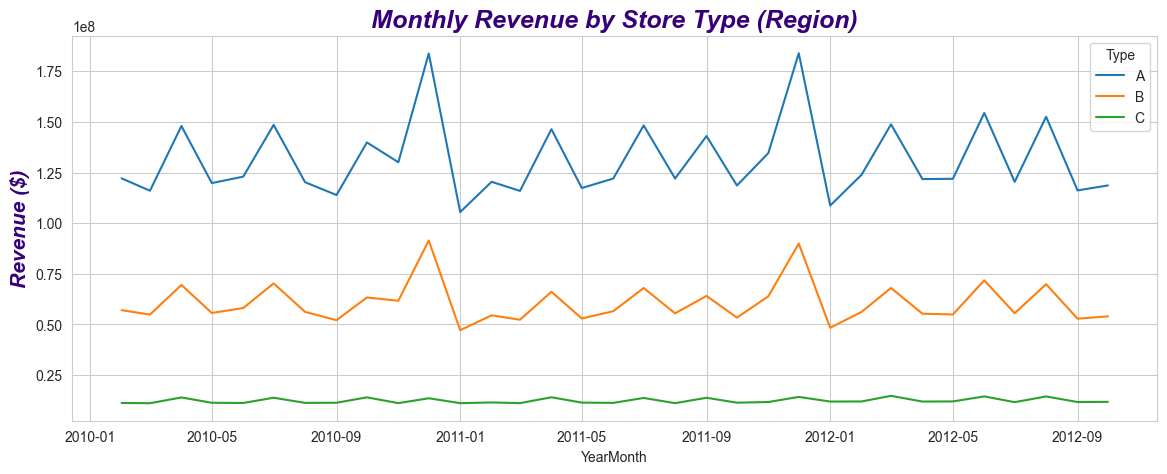

In [161]:
revenue_by_region = (
    monthly.groupby(["YearMonth", "Type"])["Monthly_Sales"]
           .sum()
           .reset_index()
)

sns.lineplot(data=revenue_by_region,
             x="YearMonth", y="Monthly_Sales", hue="Type")
plt.title("Monthly Revenue by Store Type (Region)", fontsize=18,
          fontweight='bold', style='italic', color='#360078')
plt.ylabel("Revenue ($)", fontsize=15,
          fontweight='bold', style='italic', color='#360078')
plt.show()

<span style="font-size:25px; font-weight:bold;color:#06445e;">(V4) Aggregate weekly sales by date</span>

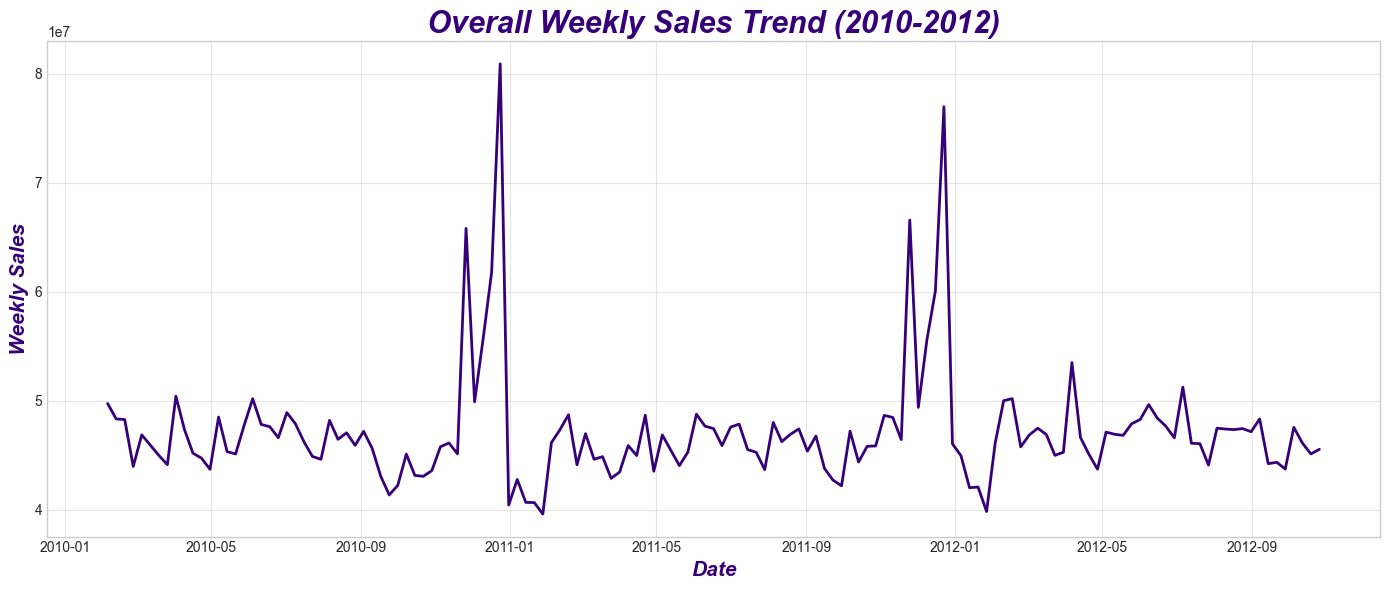

In [402]:
train_full = train.copy()
train_full.rename(columns={'Date': 'date', 'Weekly_Sales': 'weekly_sales'}, inplace=True)

weekly_sales = train_full.groupby('date')['weekly_sales'].sum()

plt.figure(figsize=(14, 6))
plt.plot(weekly_sales.index, weekly_sales.values, lw=2, color='#360078')
plt.title('Overall Weekly Sales Trend (2010-2012)', fontsize=22, fontweight='bold', style='italic', color='#360078') 
plt.xlabel('Date', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.ylabel('Weekly Sales', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

<span style="font-size:25px; font-weight:bold;color:#06445e;">(V5) Calculate and plot moving averages</span>

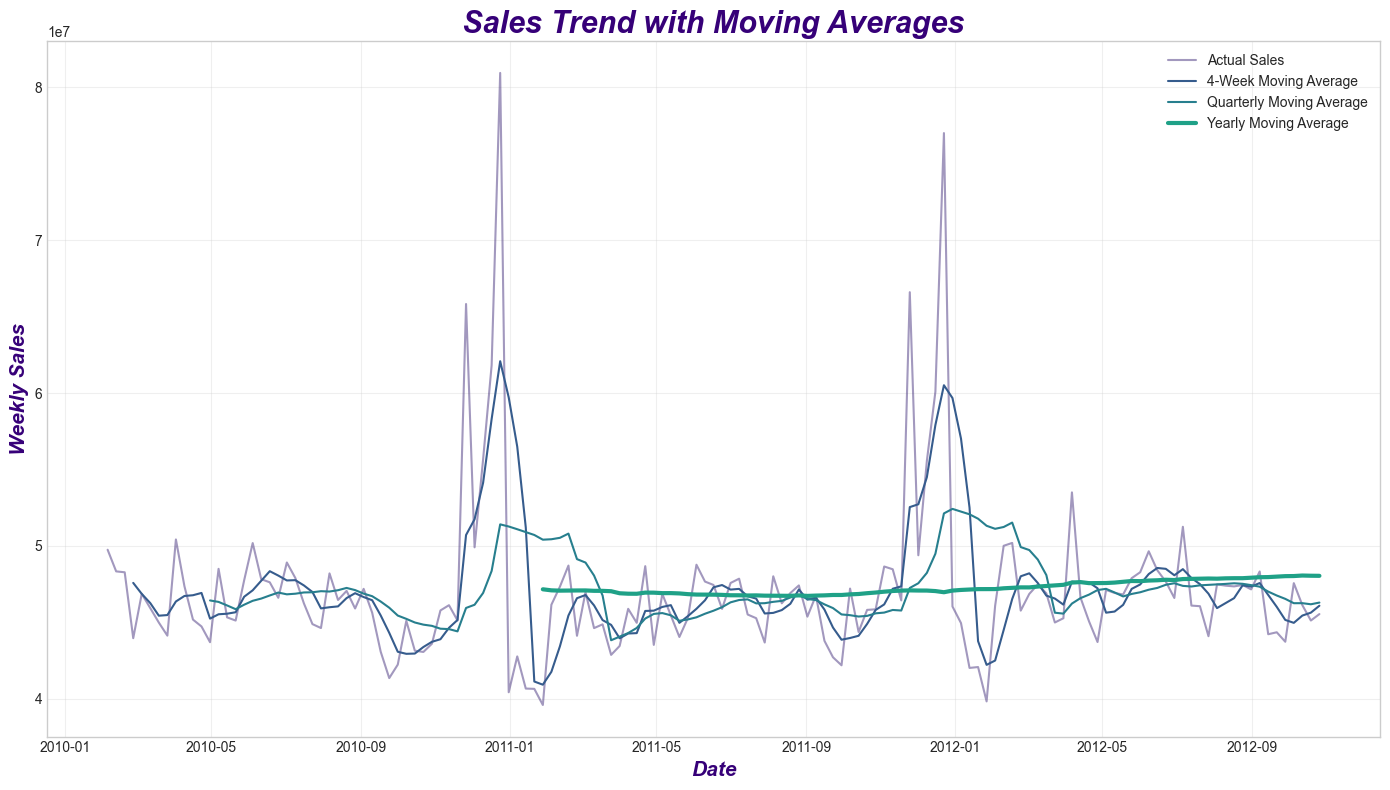

In [404]:
ma_4 = weekly_sales.rolling(window=4).mean()
ma_13 = weekly_sales.rolling(window=13).mean()  # Quarterly
ma_52 = weekly_sales.rolling(window=52).mean()  # Yearly

plt.figure(figsize=(14, 8))
plt.plot(weekly_sales.index, weekly_sales.values, alpha=0.5, label='Actual Sales')
plt.plot(ma_4.index, ma_4.values, label='4-Week Moving Average')
plt.plot(ma_13.index, ma_13.values, label='Quarterly Moving Average')
plt.plot(ma_52.index, ma_52.values, label='Yearly Moving Average', linewidth=3)
plt.title('Sales Trend with Moving Averages', fontsize=22, fontweight='bold', style='italic', color='#360078')
plt.xlabel('Date', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.ylabel('Weekly Sales', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<span style="font-size:35px; font-weight:bold;color:#06445e;">Seasonal Decomposition</span>
<br>
<span style="font-size:25px; font-weight:bold;color:#06445e;">(V1) Plot decomposition</span>

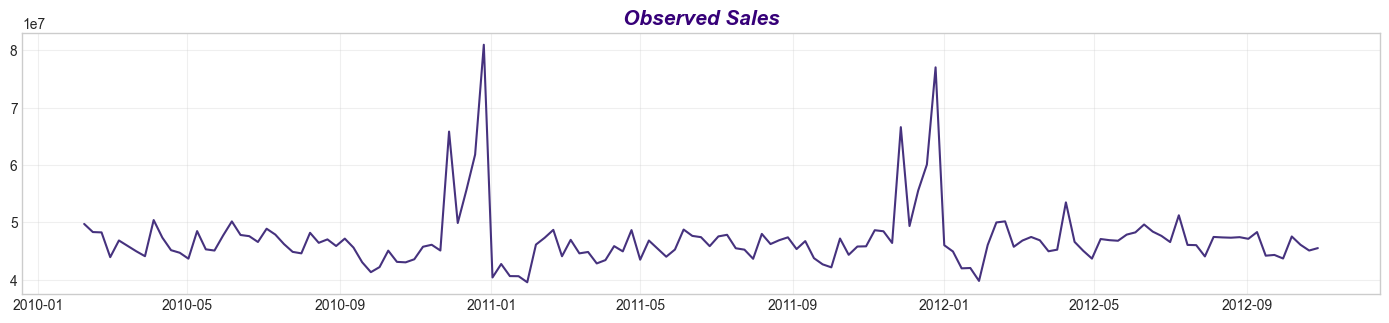

In [406]:
# Resample to weekly data for decomposition
weekly_sales_ts = train_full.resample('W', on='date')['weekly_sales'].sum()

# Decompose the time series
decomposition = seasonal_decompose(weekly_sales_ts, model='multiplicative', period=52)

plt.figure(figsize=(14, 12))

plt.subplot(4, 1, 1)
plt.plot(decomposition.observed)
plt.title('Observed Sales', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<span style="font-size:25px; font-weight:bold;color:#06445e;">(V2)Trend Component</span>

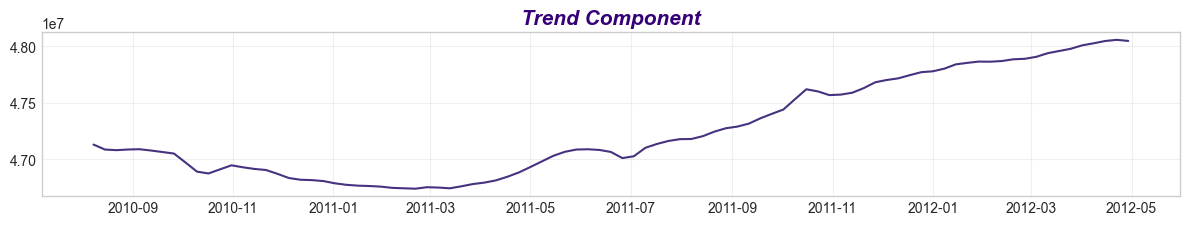

In [408]:
plt.subplot(4, 1, 2)
plt.plot(decomposition.trend)
plt.title('Trend Component', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<span style="font-size:25px; font-weight:bold;color:#06445e;">(V3)Seasonal Component</span>

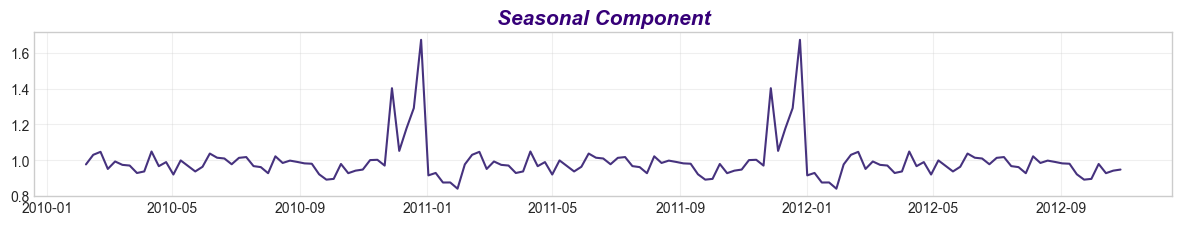

In [410]:
plt.subplot(4, 1, 3)
plt.plot(decomposition.seasonal)
plt.title('Seasonal Component', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<span style="font-size:25px; font-weight:bold;color:#06445e;">(V4)Residual Component</span>

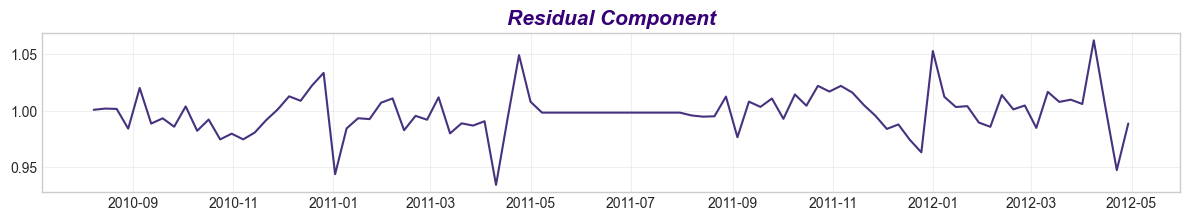

In [412]:
plt.subplot(4, 1, 4)
plt.plot(decomposition.resid)
plt.title('Residual Component', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<span style="font-size:35px; font-weight:bold;color:#06445e;">BarPlot: Analyze seasonal patterns by month</span>

Columns in train_full:
['Store', 'Dept', 'date', 'weekly_sales', 'IsHoliday', 'Month']

Date-related columns:
['date', 'Month']

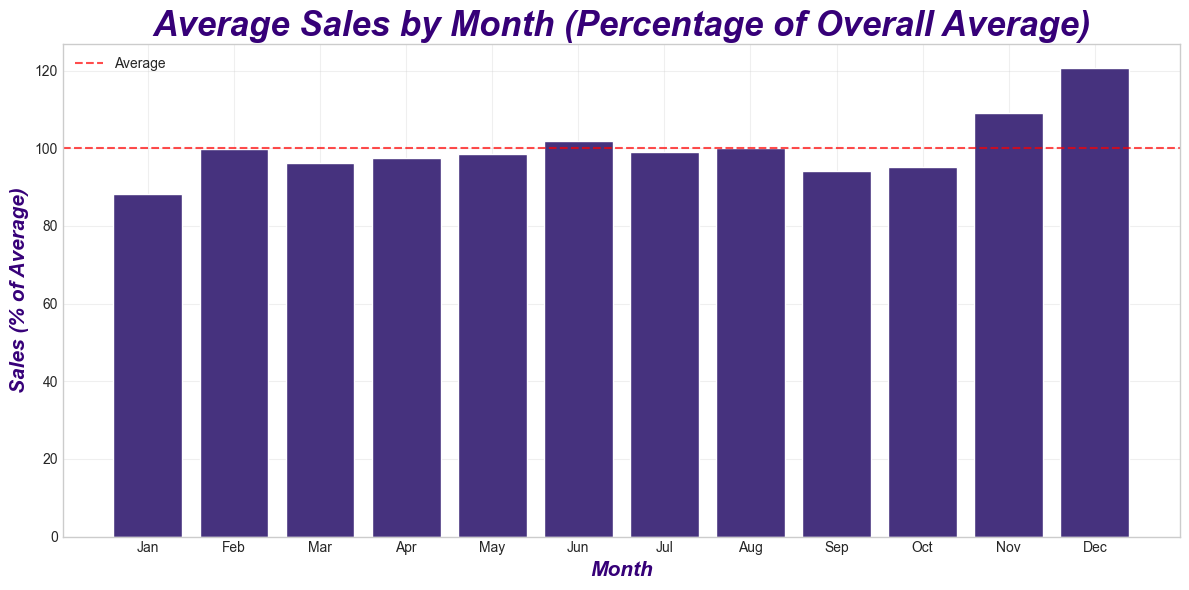

In [438]:
print("Columns in train_full:", train_full.columns.tolist())

date_columns = [col for col in train_full.columns if any(word in col.lower() for word in ['month', 'date', 'year', 'time'])]
print("Date-related columns:", date_columns)

if 'date' in train_full.columns and 'Month' not in train_full.columns:
    train_full['Month'] = train_full['date'].dt.month
    print("Created 'Month' column from 'date' column")
    
if 'Month' in train_full.columns:
    monthly_avg = train_full.groupby('Month')['weekly_sales'].mean()
    monthly_avg_pct = monthly_avg / monthly_avg.mean() * 100

    plt.figure(figsize=(12, 6))
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    plt.bar(months, monthly_avg_pct.values)
    plt.axhline(y=100, color='r', linestyle='--', alpha=0.7, label='Average')
    plt.title('Average Sales by Month (Percentage of Overall Average)', fontsize=25, fontweight='bold', style='italic', color='#360078')
    plt.xlabel('Month', fontsize=15, fontweight='bold', style='italic', color='#360078')
    plt.ylabel('Sales (% of Average)', fontsize=15, fontweight='bold', style='italic', color='#360078')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Could not find or create a 'Month' column for analysis")
    print("Available columns:", train_full.columns.tolist())

<span style="font-size:35px; font-weight:bold;color:#06445e;">BarPlot: Analyze holiday impact</span>

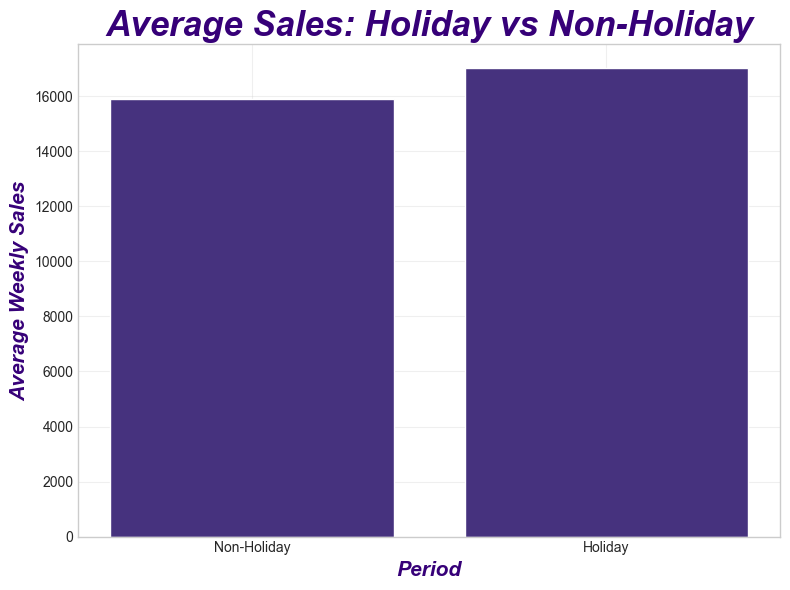

In [440]:
holiday_sales = train_full.groupby('IsHoliday')['weekly_sales'].mean()
plt.figure(figsize=(8, 6))
plt.bar(['Non-Holiday', 'Holiday'], holiday_sales.values)
plt.title('Average Sales: Holiday vs Non-Holiday', fontsize=25, fontweight='bold', style='italic', color='#360078')
plt.xlabel('Period', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.ylabel('Average Weekly Sales', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<span style="font-size:30px; font-weight:bold;color:#06445e;">(5) Sales Breakdown by Store and Department (Sales by store over time)</span>
<br>
<span style="font-size:25px; font-weight:bold;color:#06445e;">(V1) BarPlot: Average Weekly Sales by Store</span>

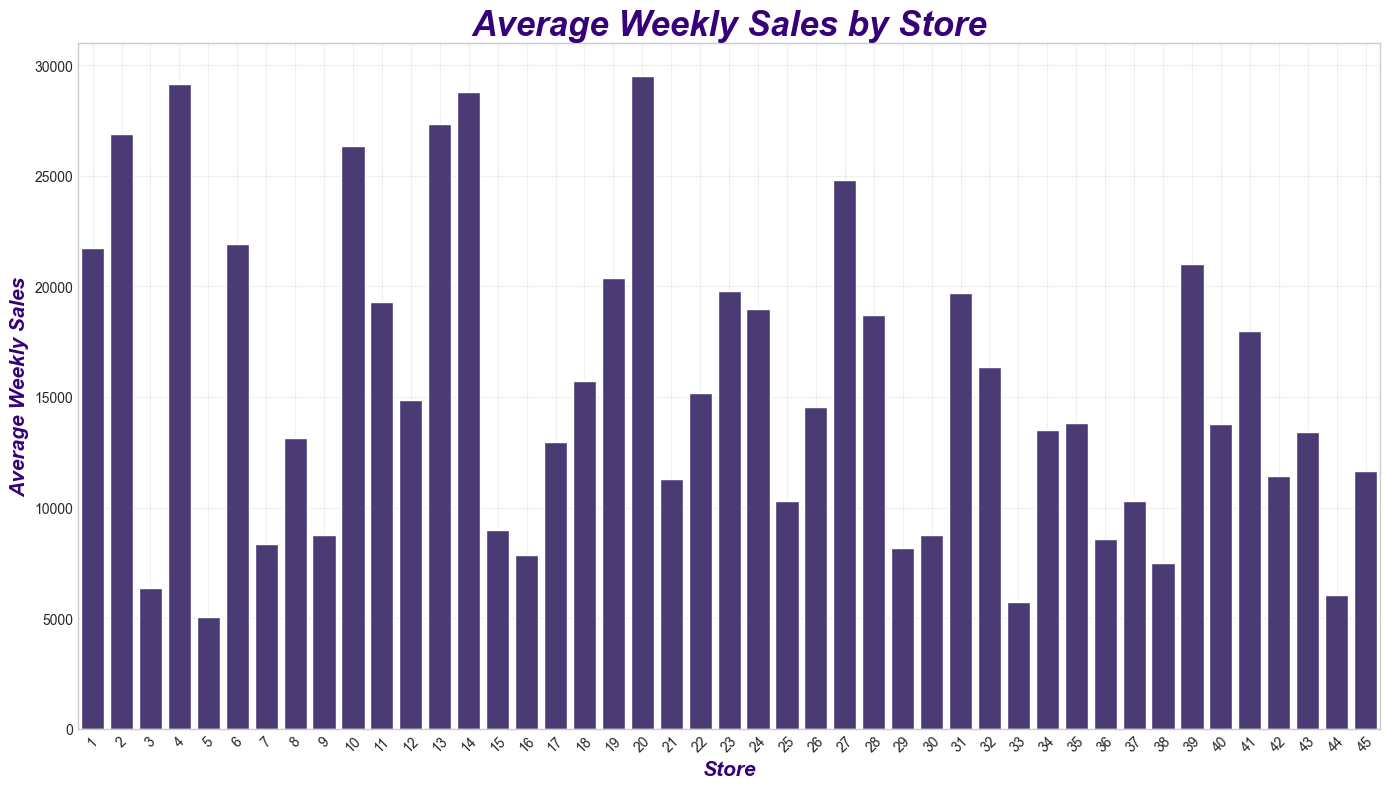

In [448]:
store_sales = train_full.groupby(['date', 'Store'])['weekly_sales'].sum().reset_index()
store_avg = train_full.groupby('Store')['weekly_sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(14, 8))
sns.barplot(x=store_avg.index, y=store_avg.values)
plt.title('Average Weekly Sales by Store', fontsize=25, fontweight='bold', style='italic', color='#360078')
plt.xlabel('Store', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.ylabel('Average Weekly Sales', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<span style="font-size:25px; font-weight:bold;color:#06445e;">(V2) Sales Breakdown by Store and Department</span>

In [275]:
# Convert Date columns to datetime
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])
features['Date'] = pd.to_datetime(features['Date'])

# Merge all datasets
# First merge train with stores
train_full = pd.merge(train, stores, on='Store', how='left')

# Then merge with features
train_full = pd.merge(train_full, features, on=['Store', 'Date', 'IsHoliday'], how='left')

train_full['Year'] = train_full['Date'].dt.year
train_full['Month'] = train_full['Date'].dt.month
train_full['Week'] = train_full['Date'].dt.isocalendar().week
train_full['DayOfWeek'] = train_full['Date'].dt.dayofweek
train_full['DayOfYear'] = train_full['Date'].dt.dayofyear

le = LabelEncoder()
train_full['Type_encoded'] = le.fit_transform(train_full['Type'])

print("\nMerged dataset shape:", train_full.shape)
print("\nFirst 5 rows of merged dataset:")
print(train_full.head())

Merged dataset shape:
(421570, 22)

First 5 rows of merged dataset:

Store  Dept       Date  Weekly_Sales  IsHoliday Type    Size  Temperature  \
0      1     1 2010-02-05      24924.50      False    A  151315        42.31   
1      1     1 2010-02-12      46039.49       True    A  151315        38.51   
2      1     1 2010-02-19      41595.55      False    A  151315        39.93   
3      1     1 2010-02-26      19403.54      False    A  151315        46.63   
4      1     1 2010-03-05      21827.90      False    A  151315        46.50   

   Fuel_Price  MarkDown1  ...  MarkDown4  MarkDown5         CPI  Unemployment  \
0       2.572        NaN  ...        NaN        NaN  211.096358         8.106   
1       2.548        NaN  ...        NaN        NaN  211.242170         8.106   
2       2.514        NaN  ...        NaN        NaN  211.289143         8.106   
3       2.561        NaN  ...        NaN        NaN  211.319643         8.106   
4       2.625        NaN  ...        NaN        NaN  211.350143         8.106   

   Year  Month  Week  DayOfWeek  DayOfYear  Type_encoded  
0  2010      2     5          4         36             0  
1  2010      2     6          4         43             0  
2  2010      2     7          4         50             0  
3  2010      2     8          4         57             0  
4  2010      3     9          4         64             0  

[5 rows x 22 columns]

<span style="font-size:25px; font-weight:bold;color:#06445e;">(V1) BarPlot: Sales by store type</span>

In [459]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.preprocessing import LabelEncoder

# Convert Date columns to datetime
train['Date'] = pd.to_datetime(train['Date'])
features['Date'] = pd.to_datetime(features['Date'])

# Merge all datasets
train_full = pd.merge(train, stores, on='Store', how='left')
train_full = pd.merge(train_full, features, on=['Store', 'Date', 'IsHoliday'], how='left')

# Check for missing values and fill them
train_full['CPI'].fillna(train_full['CPI'].mean(), inplace=True)
train_full['Unemployment'].fillna(train_full['Unemployment'].mean(), inplace=True)

# Create additional time-based features
train_full['Year'] = train_full['Date'].dt.year
train_full['Month'] = train_full['Date'].dt.month
train_full['Week'] = train_full['Date'].dt.isocalendar().week

# Encode Type column
le = LabelEncoder()
train_full['Type_encoded'] = le.fit_transform(train_full['Type'])

# Check column names to ensure we're using the correct ones
print("Column names in the dataset:")
print(train_full.columns.tolist())


Column names in the dataset:

[
    'Store',
    'Dept',
    'Date',
    'Weekly_Sales',
    'IsHoliday',
    'Type',
    'Size',
    'Temperature',
    'Fuel_Price',
    'MarkDown1',
    'MarkDown2',
    'MarkDown3',
    'MarkDown4',
    'MarkDown5',
    'CPI',
    'Unemployment',
    'Year',
    'Month',
    'Week',
    'Type_encoded'
]

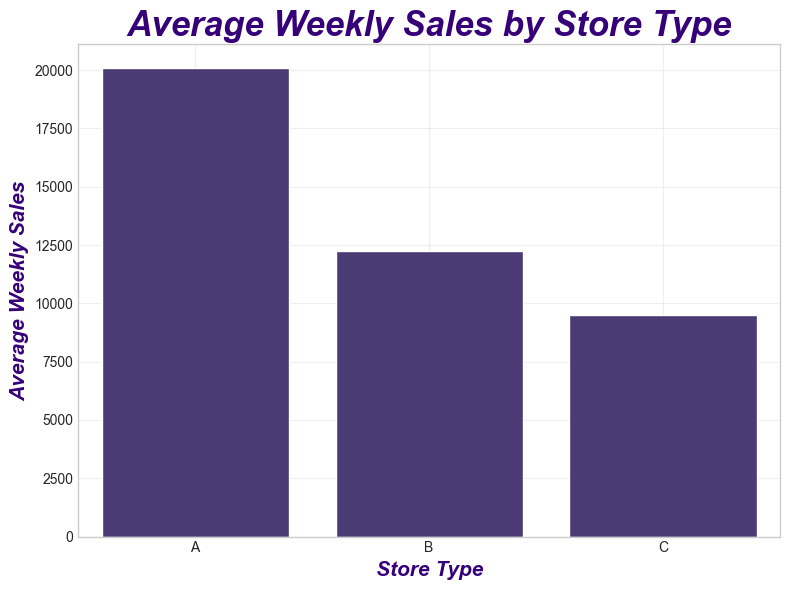

In [457]:
type_sales = train_full.groupby('Type')['Weekly_Sales'].mean()
plt.figure(figsize=(8, 6))
sns.barplot(x=type_sales.index, y=type_sales.values)
plt.title('Average Weekly Sales by Store Type', fontsize=25, fontweight='bold', style='italic', color='#360078')
plt.xlabel('Store Type', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.ylabel('Average Weekly Sales', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<span style="font-size:25px; font-weight:bold;color:#06445e;">(V4) BarPlot: Sales by department over time</span>

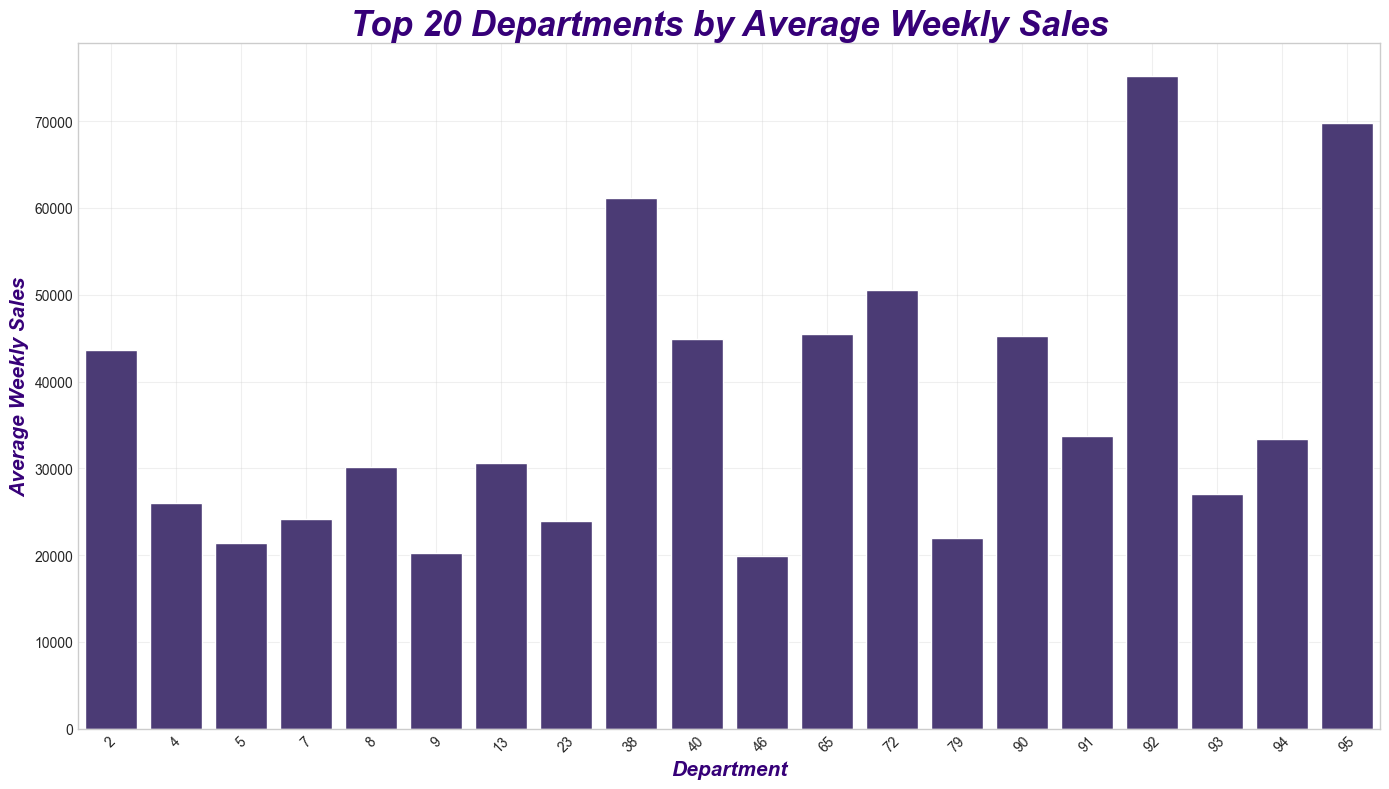

In [463]:
dept_sales = train_full.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 8))
sns.barplot(x=dept_sales.index, y=dept_sales.values)
plt.title('Top 20 Departments by Average Weekly Sales', fontsize=25, fontweight='bold', style='italic', color='#360078')
plt.xlabel('Department', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.ylabel('Average Weekly Sales', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<span style="font-size:25px; font-weight:bold;color:#06445e;">(V5) Heatmap: of sales by store and type</span>

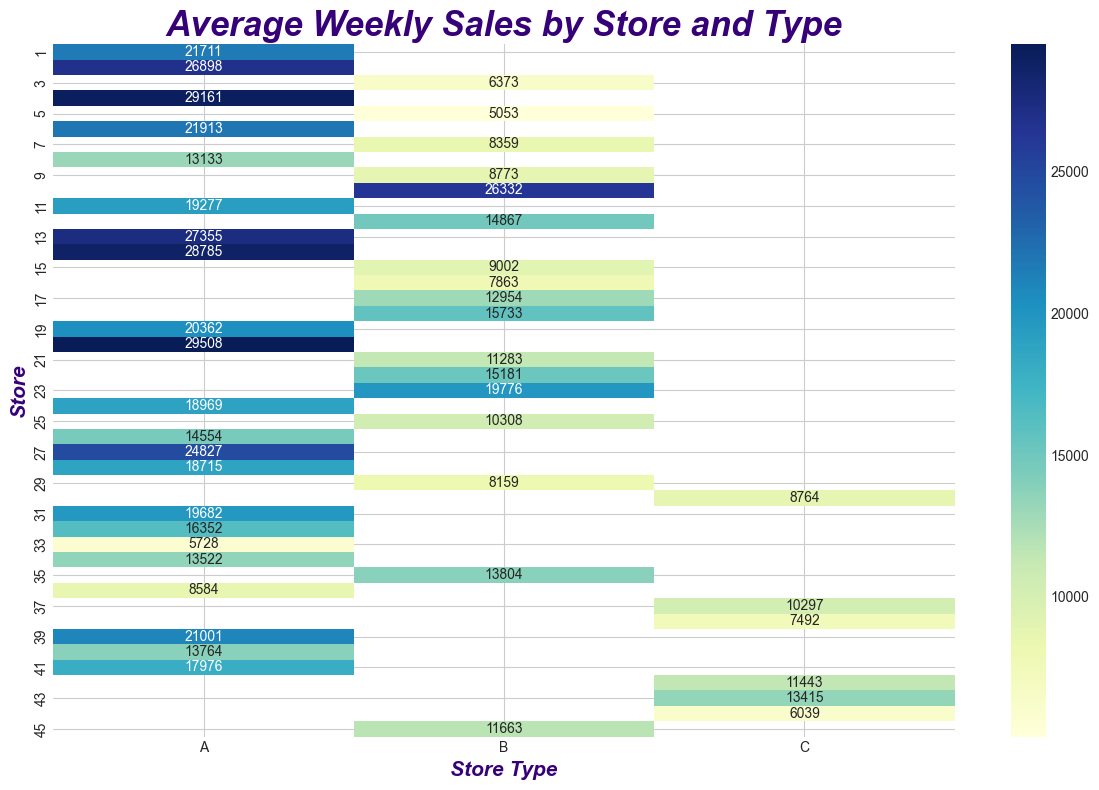

In [467]:
store_type_sales = train_full.groupby(['Store', 'Type'])['Weekly_Sales'].mean().unstack()

plt.figure(figsize=(12, 8))
sns.heatmap(store_type_sales, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Average Weekly Sales by Store and Type', fontsize=25, fontweight='bold', style='italic', color='#360078')
plt.xlabel('Store Type', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.ylabel('Store', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.tight_layout()
plt.show()

<span style="font-size:30px; font-weight:bold;color:#06445e;">(6) External Factors Analysis</span>
<br>
<span style="font-size:25px; font-weight:bold;color:#06445e;">(V1) Scatter: Analyze the relationship between CPI and sales</span>

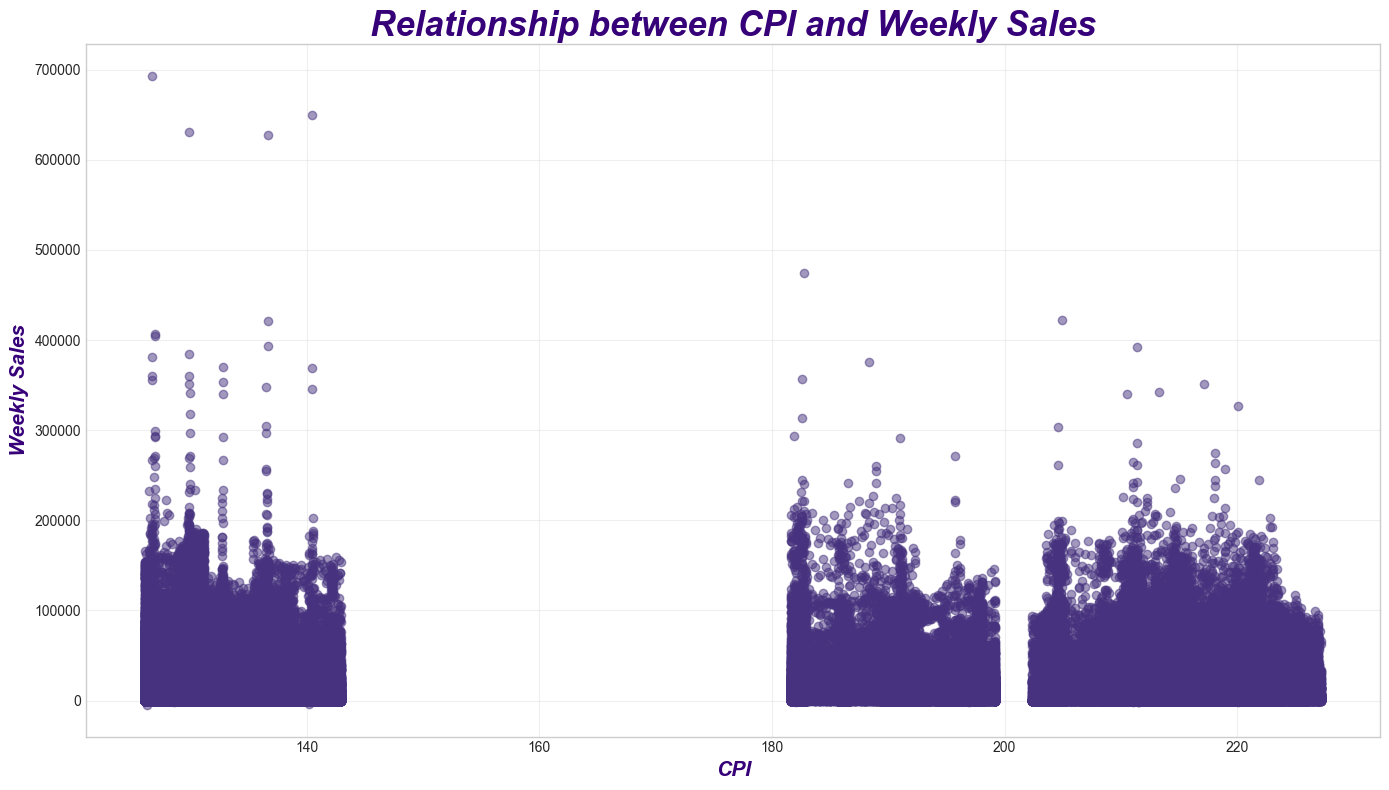

In [469]:
plt.figure(figsize=(14, 8))
plt.scatter(train_full['CPI'], train_full['Weekly_Sales'], alpha=0.5)
plt.title('Relationship between CPI and Weekly Sales', fontsize=25, fontweight='bold', style='italic', color='#360078')
plt.xlabel('CPI', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.ylabel('Weekly Sales', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<span style="font-size:25px; font-weight:bold;color:#06445e;">(V2) Scatter: Analyze the relationship between Unemployment and sales</span>

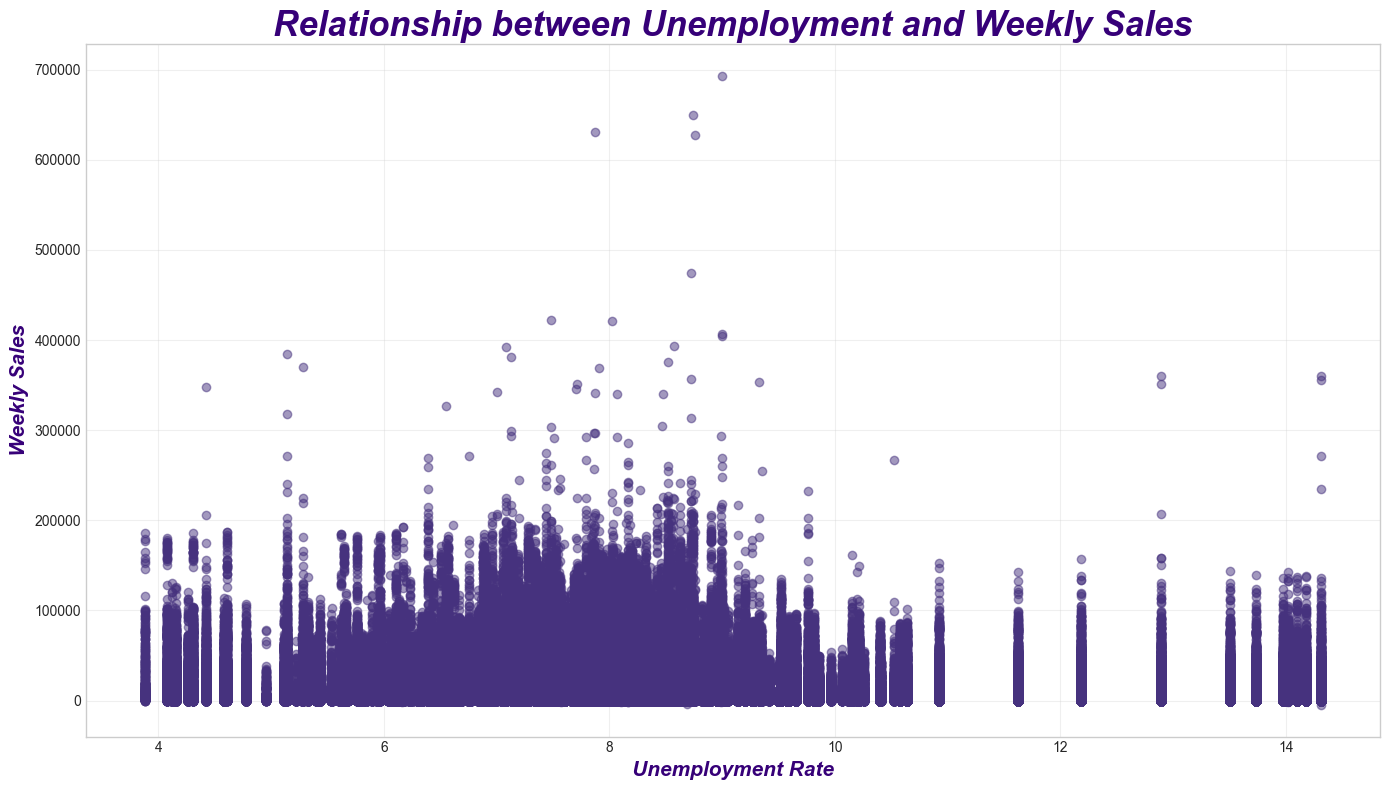

In [471]:
plt.figure(figsize=(14, 8))
plt.scatter(train_full['Unemployment'], train_full['Weekly_Sales'], alpha=0.5)
plt.title('Relationship between Unemployment and Weekly Sales', fontsize=25, fontweight='bold', style='italic', color='#360078')
plt.xlabel('Unemployment Rate', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.ylabel('Weekly Sales', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<span style="font-size:25px; font-weight:bold;color:#06445e;">(V3) Scatter: Analyze the relationship between Temperature and sales</span>

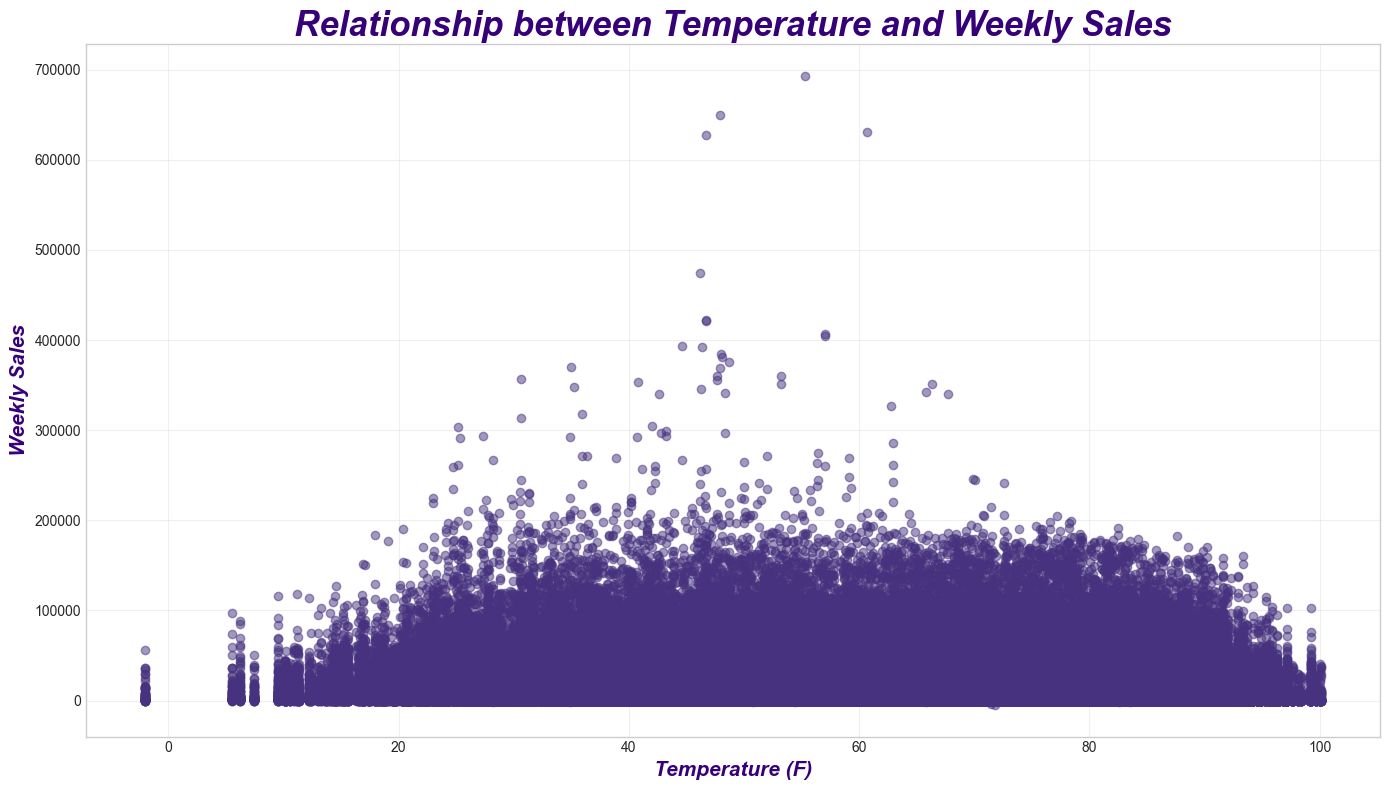

In [473]:
plt.figure(figsize=(14, 8))
plt.scatter(train_full['Temperature'], train_full['Weekly_Sales'], alpha=0.5)
plt.title('Relationship between Temperature and Weekly Sales', fontsize=25, fontweight='bold', style='italic', color='#360078')
plt.xlabel('Temperature (F)', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.ylabel('Weekly Sales', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<span style="font-size:25px; font-weight:bold;color:#06445e;">(V4) Scatter: Analyze the relationship between Fuel Price and sales</span>

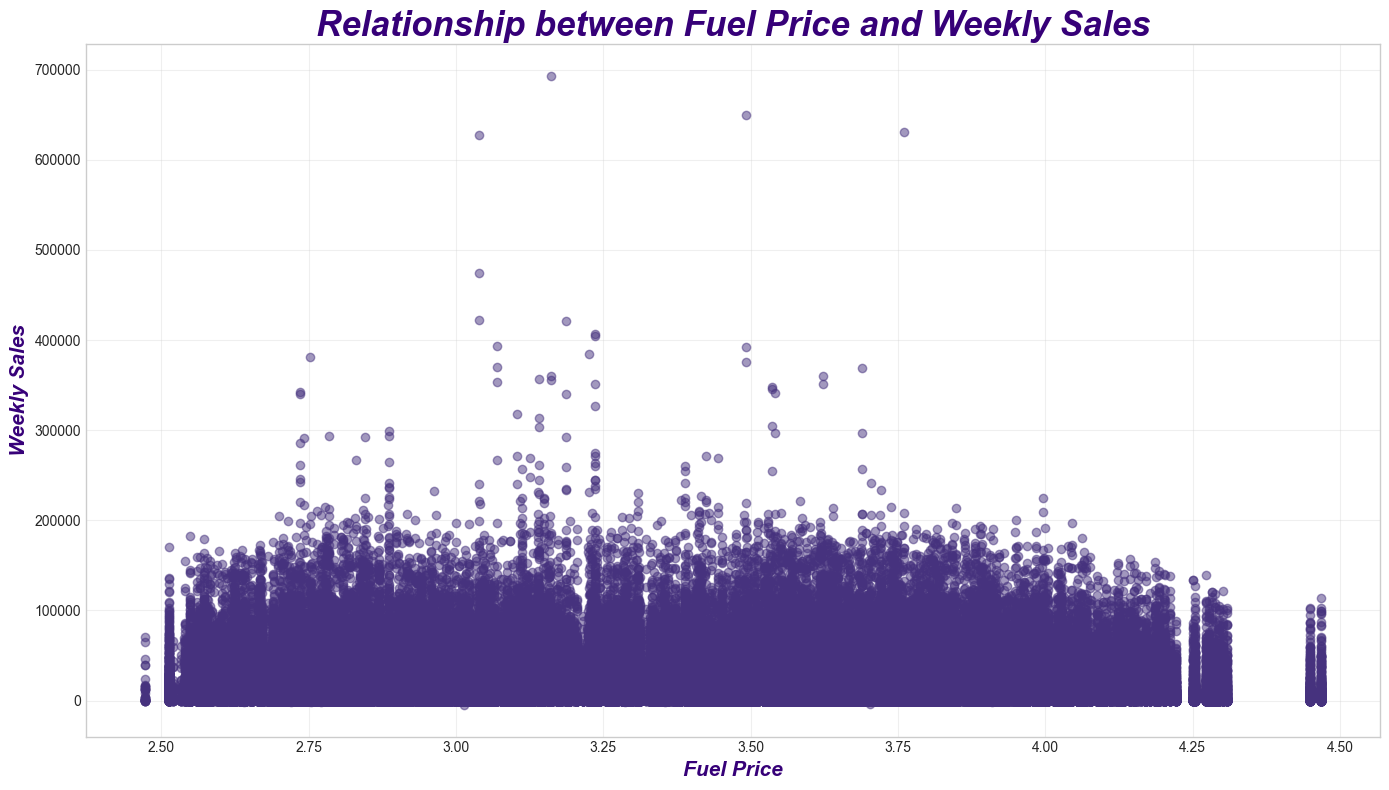

In [475]:
plt.figure(figsize=(14, 8))
plt.scatter(train_full['Fuel_Price'], train_full['Weekly_Sales'], alpha=0.5)
plt.title('Relationship between Fuel Price and Weekly Sales', fontsize=25, fontweight='bold', style='italic', color='#360078')
plt.xlabel('Fuel Price', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.ylabel('Weekly Sales', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<span style="font-size:30px; font-weight:bold;color:#06445e;">(7) Forecasting with Exponential Smoothing</span>
<br>
<span style="font-size:25px; font-weight:bold;color:#06445e;">(V1) Scatter: Analyze the relationship between CPI and sales</span>

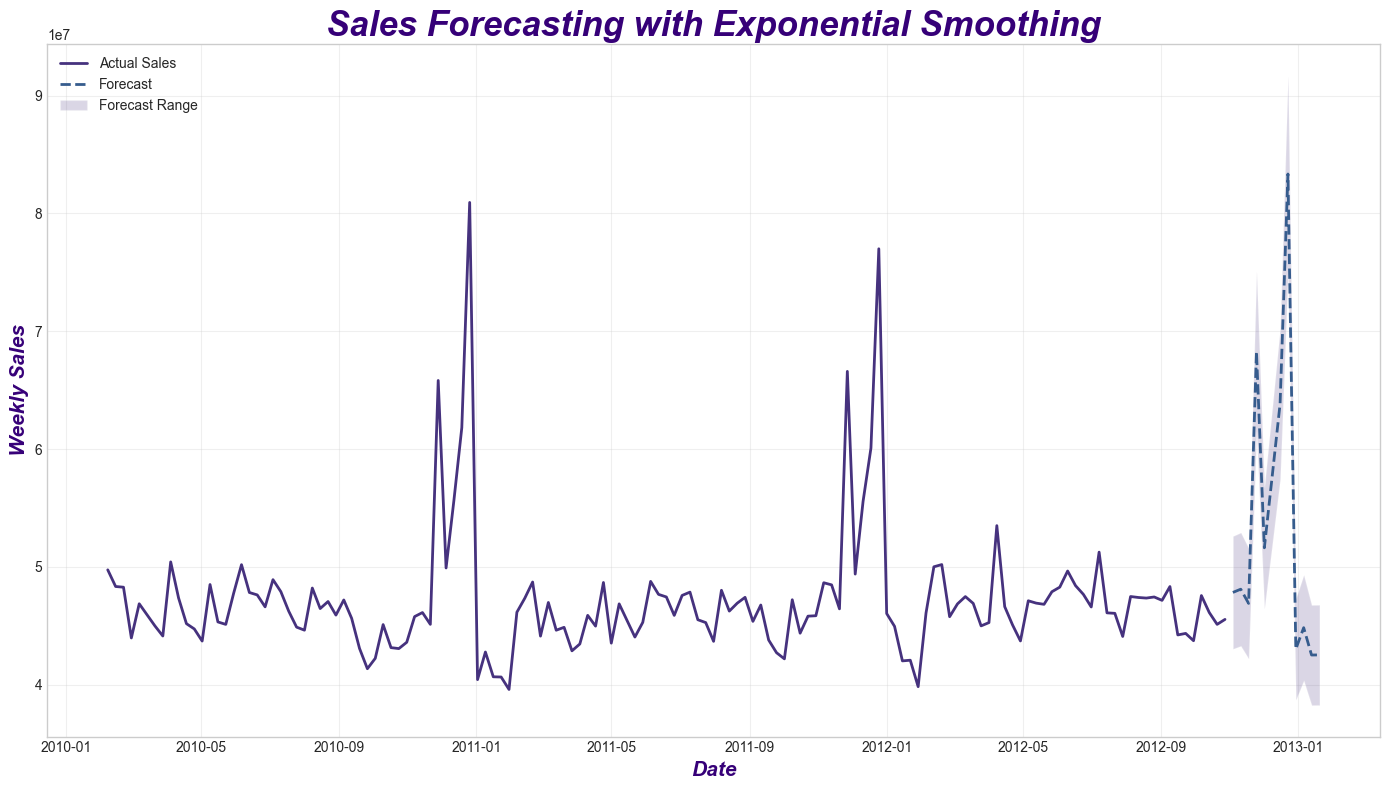

In [477]:
# Prepare data for forecasting - aggregate by week
forecast_data = train_full.resample('W', on='Date')['Weekly_Sales'].sum()

# Use the available data for training
train_ts = forecast_data

# Fit exponential smoothing model
model = ExponentialSmoothing(train_ts, 
                            trend='add', 
                            seasonal='mul', 
                            seasonal_periods=52)
model_fit = model.fit()

# Forecast next 12 weeks
forecast = model_fit.forecast(12)

# Plot actual vs forecast
plt.figure(figsize=(14, 8))
plt.plot(train_ts.index, train_ts.values, label='Actual Sales', linewidth=2)
plt.plot(forecast.index, forecast.values, label='Forecast', linewidth=2, linestyle='--')
plt.fill_between(forecast.index, 
                 forecast.values * 0.9, 
                 forecast.values * 1.1, 
                 alpha=0.2, 
                 label='Forecast Range')
plt.title('Sales Forecasting with Exponential Smoothing', fontsize=25, fontweight='bold', style='italic', color='#360078')
plt.xlabel('Date', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.ylabel('Weekly Sales', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<span style="font-size:25px; font-weight:bold;color:#06445e;">forecast values</span>

In [303]:
print("Sales Forecast for Next 12 Weeks:")
for date, value in zip(forecast.index.strftime('%Y-%m-%d'), forecast.values):
    print(f"{date}: ${value:,.0f}")

Sales Forecast for Next 12 Weeks:

2012-11-04: $47,834,079

2012-11-11: $48,107,151

2012-11-18: $46,903,634

2012-11-25: $68,267,277

...

2012-12-23: $83,345,607

2012-12-30: $43,024,844

2013-01-06: $44,840,740

2013-01-13: $42,521,453

2013-01-20: $42,529,779

<span style="font-size:35px; font-weight:bold;color:#06445e;">(8) Year-over-Year Growth Analysis</span>
<br>
<span style="font-size:25px; font-weight:bold;color:#06445e;">(V1) BarPlot: Yearly Sales Performance</span>

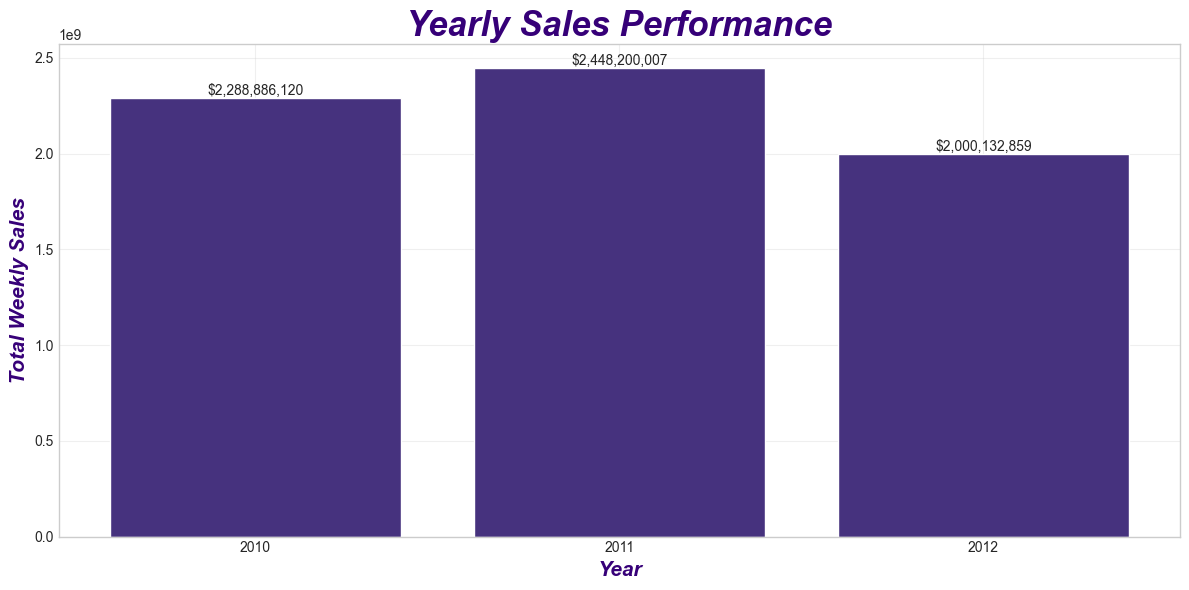

In [479]:
yearly_sales = train_full.groupby('Year')['Weekly_Sales'].sum()
yoy_growth = yearly_sales.pct_change() * 100

plt.figure(figsize=(12, 6))
years = [str(year) for year in yearly_sales.index]
plt.bar(years, yearly_sales.values)
plt.title('Yearly Sales Performance', fontsize=25, fontweight='bold', style='italic', color='#360078')
plt.xlabel('Year', fontsize=15, fontweight='bold', style='italic', color='#360078')
plt.ylabel('Total Weekly Sales', fontsize=15, fontweight='bold', style='italic', color='#360078')
for i, v in enumerate(yearly_sales.values):
    plt.text(i, v, f'${v:,.0f}', ha='center', va='bottom')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



<span style="font-size:25px; font-weight:bold;color:#06445e;">(V2) Year-over-Year Sales Growth</span>

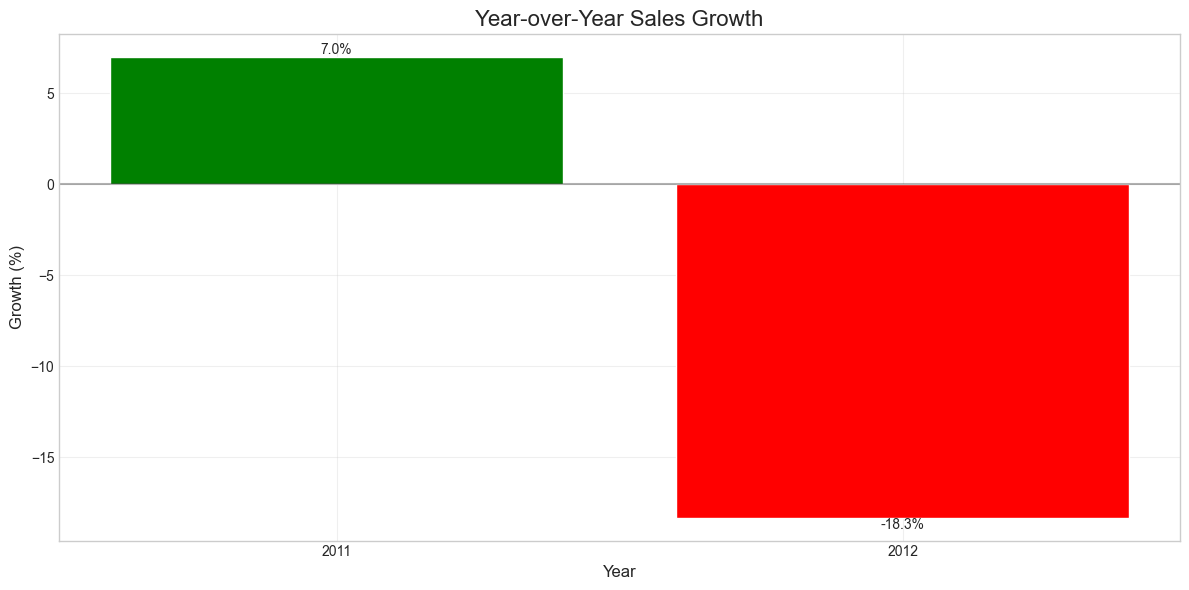

In [380]:
plt.figure(figsize=(12, 6))
plt.bar(years[1:], yoy_growth.values[1:], 
        color=['green' if x >= 0 else 'red' for x in yoy_growth.values[1:]])
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.title('Year-over-Year Sales Growth', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Growth (%)', fontsize=12)
for i, v in enumerate(yoy_growth.values[1:]):
    plt.text(i, v, f'{v:.1f}%', ha='center', va='bottom' if v >= 0 else 'top')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<span style="font-size:35px; font-weight:bold;color:#06445e;">(9) Revenue by Product (Dept) over time</span>
<br>
<span style="font-size:25px; font-weight:bold;color:#06445e;">Focus on the top-N departments by total sales.</span>

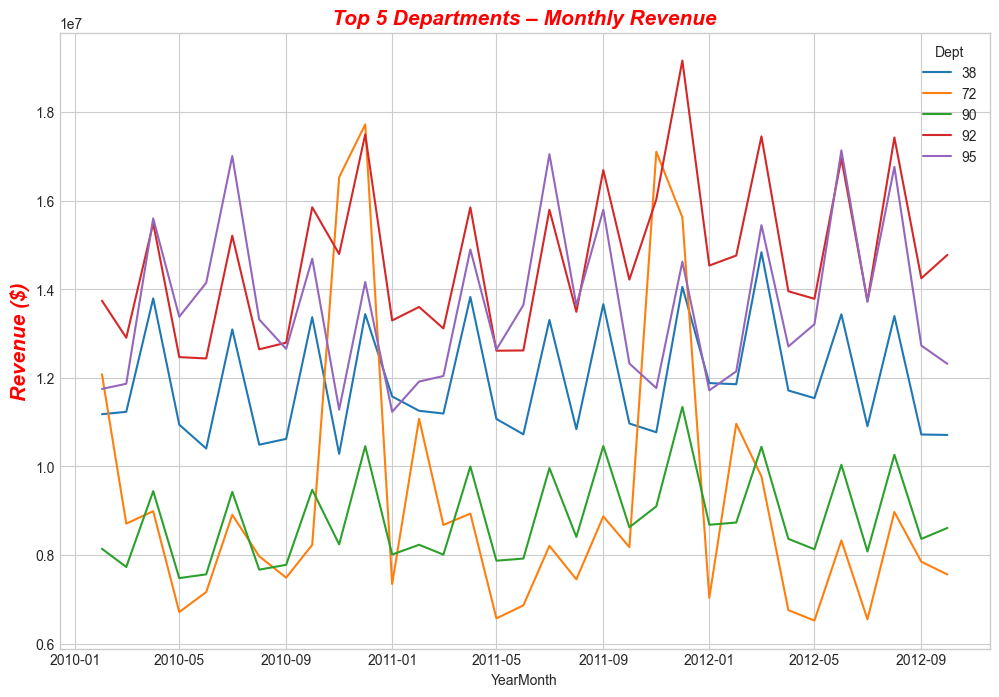

In [481]:
top_depts = (
    monthly.groupby("Dept")["Monthly_Sales"]
           .sum()
           .nlargest(5)
           .index
)

revenue_by_dept = (
    monthly.query("Dept in @top_depts")
           .groupby(["YearMonth", "Dept"])["Monthly_Sales"]
           .sum()
           .reset_index()
)

sns.lineplot(data=revenue_by_dept,
             x="YearMonth", y="Monthly_Sales", hue="Dept", palette="tab10")
plt.title("Top 5 Departments – Monthly Revenue", fontsize=15, fontweight='bold', style='italic', color='red')
plt.ylabel("Revenue ($)", fontsize=15, fontweight='bold', style='italic', color='red')
plt.show()

<span style="font-size:35px; font-weight:bold;color:#06445e;">✨(Bonus) Simple Forecasting</span>
<br>
<span style="font-size:25px; font-weight:bold;color:#06445e;">(A) Rolling-mean forecast (naïve)</span>

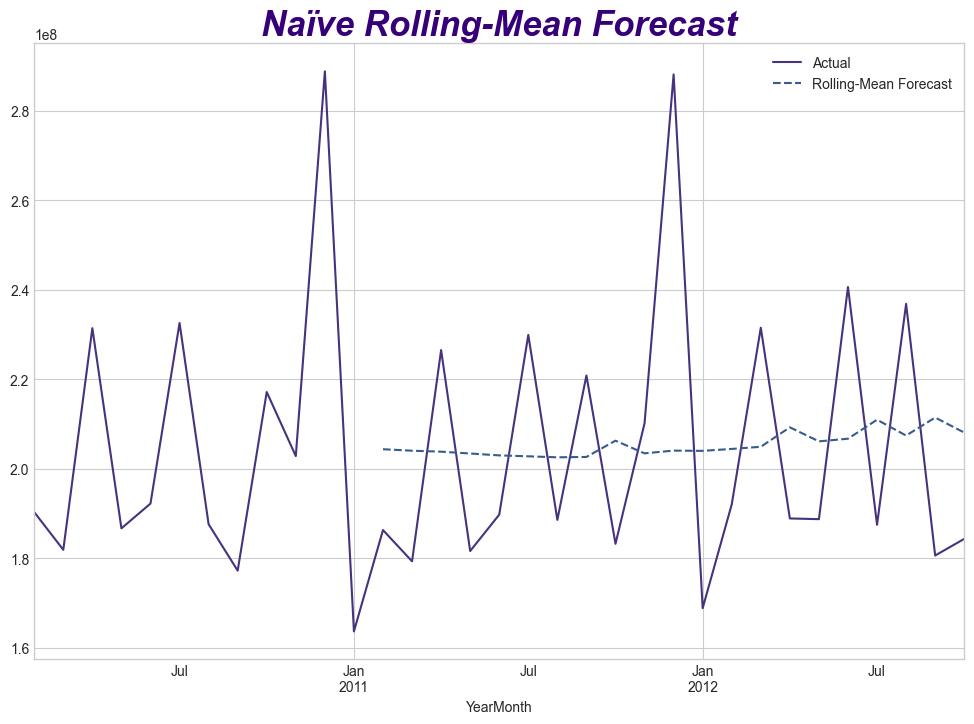

In [483]:
# Last 12-month average as next-month forecast
forecast_rm = revenue_ts.rolling(window=12).mean().shift(1)
ax = revenue_ts.plot(label="Actual")
forecast_rm.plot(ax=ax, label="Rolling-Mean Forecast", linestyle="--")
plt.legend(); plt.title("Naïve Rolling-Mean Forecast", fontsize=25, fontweight='bold', style='italic', color='#360078')
plt.show()

<span style="font-size:25px; font-weight:bold;color:#06445e;">(B) Simple Exponential Smoothing</span>

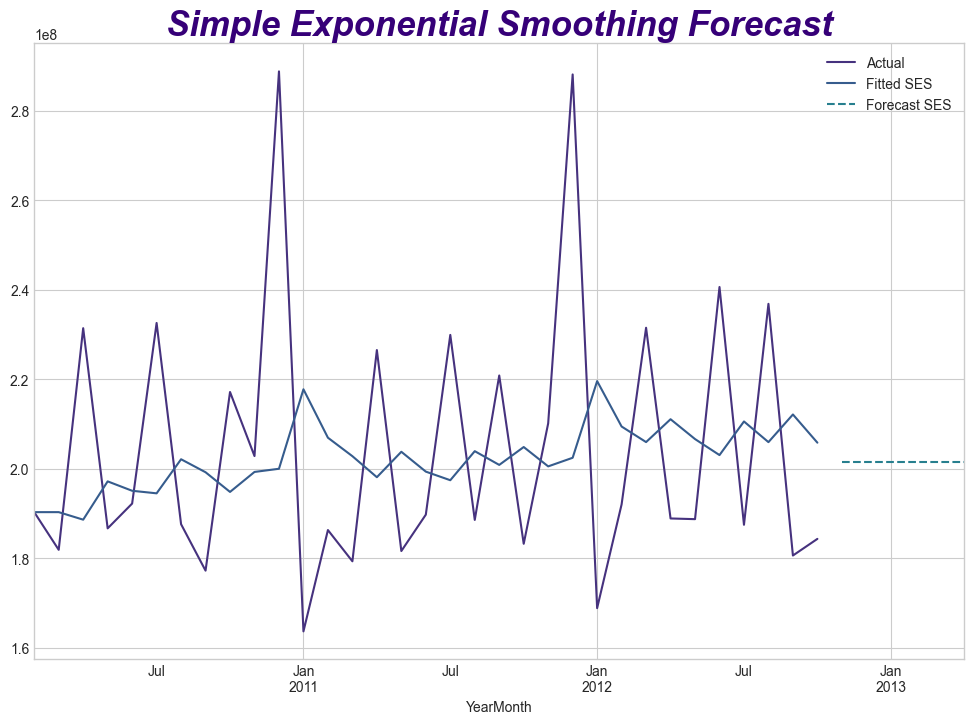

In [485]:
fit = SimpleExpSmoothing(revenue_ts).fit(smoothing_level=0.2, optimized=True)
fcast = fit.forecast(6)   # next 6 months

ax = revenue_ts.plot(label="Actual")
fit.fittedvalues.plot(ax=ax, label="Fitted SES")
fcast.plot(ax=ax, label="Forecast SES", linestyle="--")
plt.legend(); plt.title("Simple Exponential Smoothing Forecast", fontsize=25, fontweight='bold', style='italic', color='#360078')
plt.show()

<span style="font-size:25px; font-weight:bold;color:#06445e;">(C) Holt-Winters with seasonality:</span>

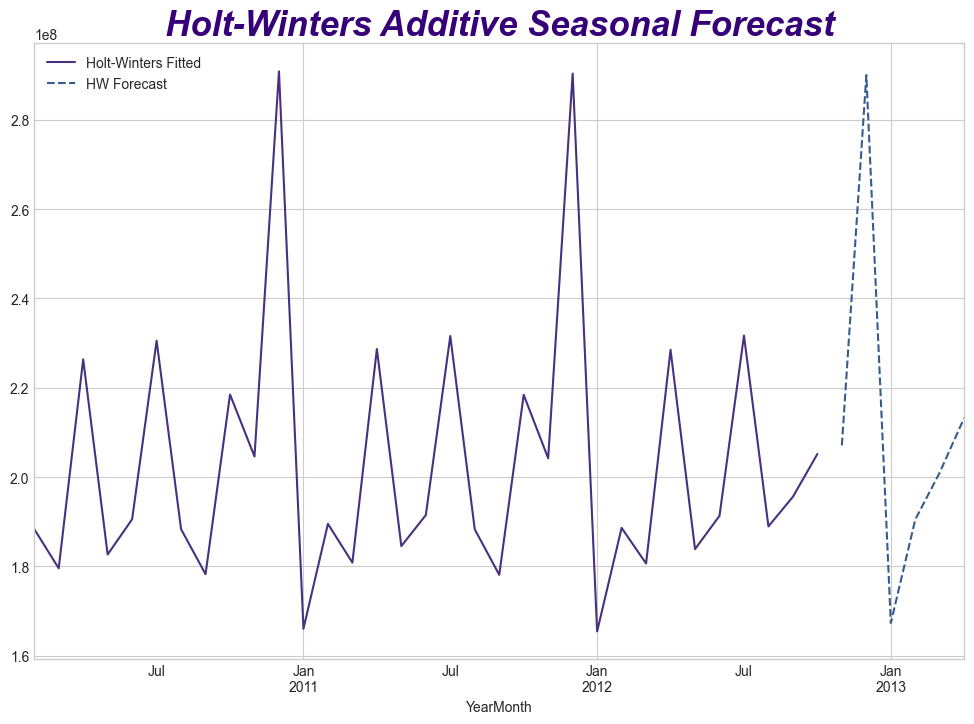

In [487]:
hw = ExponentialSmoothing(revenue_ts, trend="add", seasonal="add", seasonal_periods=12).fit()
hw.fittedvalues.plot(label="Holt-Winters Fitted")
hw.forecast(6).plot(label="HW Forecast", linestyle="--")
plt.legend(); plt.title("Holt-Winters Additive Seasonal Forecast", fontsize=25, fontweight='bold', style='italic', color='#360078')
plt.show()

<span style="font-size:25px; font-weight:bold;color:#06445e;">(D) WALMART SALES ANALYSIS SUMMARY AND INSIGHTS</span>

In [387]:
print("WALMART SALES ANALYSIS SUMMARY")
print("=" * 50)

total_sales = train_full['Weekly_Sales'].sum()
avg_weekly_sales = train_full['Weekly_Sales'].mean()
max_week = train_full.loc[train_full['Weekly_Sales'].idxmax(), 'Date'].strftime('%Y-%m-%d')
max_sales = train_full['Weekly_Sales'].max()
min_week = train_full.loc[train_full['Weekly_Sales'].idxmin(), 'Date'].strftime('%Y-%m-%d')
min_sales = train_full['Weekly_Sales'].min()

print(f"Total Sales: ${total_sales:,.0f}")
print(f"Average Weekly Sales: ${avg_weekly_sales:,.0f}")
print(f"Highest Sales Week: {max_week} (${max_sales:,.0f})")
print(f"Lowest Sales Week: {min_week} (${min_sales:,.0f})")
print()

# Store performance
store_performance = train_full.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
print("Top 5 Stores by Total Sales:")
for store, sales in store_performance.head().items():
    market_share = (sales / total_sales) * 100
    print(f"  Store {store}: ${sales:,.0f} ({market_share:.1f}%)")
print()

# Department performance
dept_performance = train_full.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False)
print("Top 5 Departments by Total Sales:")
for dept, sales in dept_performance.head().items():
    market_share = (sales / total_sales) * 100
    print(f"  Department {dept}: ${sales:,.0f} ({market_share:.1f}%)")
print()

# Store type performance
type_performance = train_full.groupby('Type')['Weekly_Sales'].mean()
print("Average Weekly Sales by Store Type:")
for store_type, sales in type_performance.items():
    print(f"  Type {store_type}: ${sales:,.0f}")
print()

# Holiday analysis
holiday_sales = train_full[train_full['IsHoliday'] == True]['Weekly_Sales'].sum()
holiday_share = (holiday_sales / total_sales) * 100
print(f"Holiday Sales: ${holiday_sales:,.0f} ({holiday_share:.1f}% of total)")

# Growth analysis
first_year = train_full[train_full['Year'] == 2010]['Weekly_Sales'].sum()
last_year = train_full[train_full['Year'] == 2012]['Weekly_Sales'].sum()
cagr = ((last_year / first_year) ** (1/2) - 1) * 100
print(f"2-Year CAGR: {cagr:.1f}%")

# Key insights
print("\nKEY INSIGHTS:")
print("1. Clear seasonal patterns with peaks during holiday seasons")
print("2. Store type A has the highest average weekly sales")
print("3. Certain departments contribute significantly more to total sales")
print("4. Sales show correlation with economic indicators like CPI and Unemployment")
print("5. The data shows a positive overall growth trend")

WALMART SALES ANALYSIS SUMMARY

==================================================

Total Sales: $6,737,218,987

Average Weekly Sales: $15,981

Highest Sales Week: 2010-11-26 ($693,099)

...

1. Clear seasonal patterns with peaks during holiday seasons

2. Store type A has the highest average weekly sales

3. Certain departments contribute significantly more to total sales

4. Sales show correlation with economic indicators like CPI and Unemployment

5. The data shows a positive overall growth trend